In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

planner_strategy = pd.read_csv('value-functions/goal_value_function_mean.csv')
planner_strategy = planner_strategy[~planner_strategy.isin(['SUMMARY', 'SUMMARY_ROW']).any(axis=1)]
planner_strategy = planner_strategy.drop(['metric', 'metric_value'], axis=1)
# Normalize from values to probabilities of selecting each goal (strategy)
planner_strategy_probabilities = planner_strategy['value'] / planner_strategy['value'].sum()
# Convert to log probabilities for numerical stability
planner_strategy['log_probability_planner'] = np.log(planner_strategy_probabilities)

concept_strategy = pd.read_csv('state_probabilities.csv')
concept_strategy = concept_strategy.rename(columns={'log_probability': 'log_probability_concept'})



# Plot the planner strategy (individual plots)

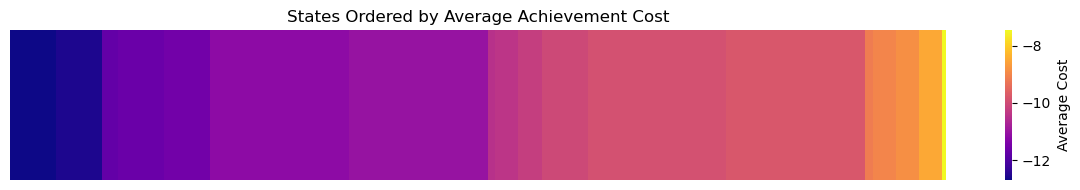

In [43]:
planner_strategy_sort = planner_strategy.sort_values(by='value', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12,2))
planner_strat_reshaped = planner_strategy_sort['value'].values.reshape(-1, 1)

sns.heatmap(planner_strat_reshaped.T, cmap='plasma', cbar_kws={'label': 'Average Cost'}, ax=ax)

# Configure labels
ax.set_yticks([])
ax.set_xticks([])
plt.title('States Ordered by Average Achievement Cost')
plt.tight_layout()

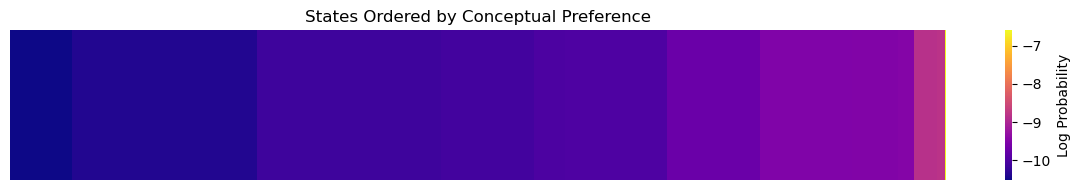

In [44]:
# Order states by conceptual preference
concept_strategy_sort = concept_strategy.sort_values(by='log_probability_concept', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12,2))
concept_strategy_reshaped = concept_strategy_sort['log_probability_concept'].values.reshape(-1, 1)

sns.heatmap(concept_strategy_reshaped.T, cmap='plasma', cbar_kws={'label': 'Log Probability'}, ax=ax)

# Configure labels
ax.set_yticks([])
ax.set_xticks([])
plt.title('States Ordered by Conceptual Preference')
plt.tight_layout()


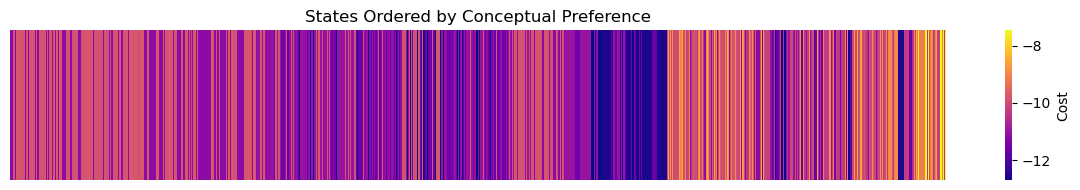

In [45]:
# merge the two dataframes on the common columns
merge_columns = [
    'shape1_sides', 'shape1_shade', 'shape1_texture',
    'shape2_sides', 'shape2_shade', 'shape2_texture',
    'shape3_sides', 'shape3_shade', 'shape3_texture'
]

merged_df = pd.merge(planner_strategy, concept_strategy[merge_columns + ['log_probability_concept']], 
                     on=merge_columns, how='inner')

merged_sort_by_cost = merged_df.copy().sort_values(by='value', ascending=True).reset_index(drop=True)
cost_reshaped_sort_by_cost = merged_sort_by_cost['value'].values.reshape(-1, 1)

merged_sort_by_concept = merged_df.copy().sort_values(by='log_probability_concept', ascending=True).reset_index(drop=True)
cost_reshaped_sort_by_concept = merged_sort_by_concept['value'].values.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(12,2))

sns.heatmap(cost_reshaped_sort_by_concept.T, cmap='plasma', cbar_kws={'label': 'Cost'}, ax=ax)

# Configure labels
ax.set_yticks([])
ax.set_xticks([])
plt.title('States Ordered by Conceptual Preference')
plt.tight_layout()


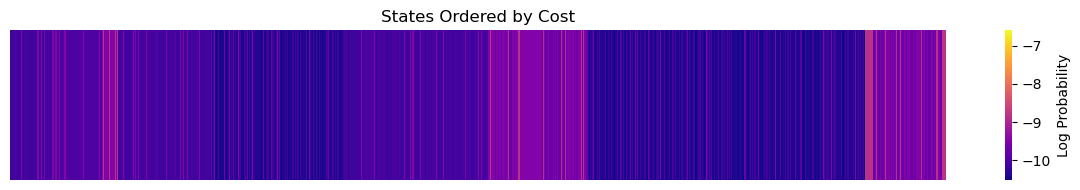

In [47]:
# merge the two dataframes on the common columns
merge_columns = [
    'shape1_sides', 'shape1_shade', 'shape1_texture',
    'shape2_sides', 'shape2_shade', 'shape2_texture',
    'shape3_sides', 'shape3_shade', 'shape3_texture'
]

merged_df = pd.merge(planner_strategy, concept_strategy[merge_columns + ['log_probability_concept']], 
                     on=merge_columns, how='inner')

# sort by conceptual preference
merged_sort_by_concept = merged_df.copy().sort_values(by='log_probability_concept', ascending=True).reset_index(drop=True)
concept_reshaped_sort_by_concept = merged_sort_by_concept['log_probability_concept'].values.reshape(-1, 1)

# sort by cost, but display conceptual preference
merged_sort_by_cost = merged_df.copy().sort_values(by='value', ascending=True).reset_index(drop=True)
concept_reshaped_sort_by_cost = merged_sort_by_cost['log_probability_concept'].values.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(12,2))

sns.heatmap(concept_reshaped_sort_by_cost.T, cmap='plasma', cbar_kws={'label': 'Log Probability'}, ax=ax)

# Configure labels
ax.set_yticks([])
ax.set_xticks([])
plt.title('States Ordered by Cost')
plt.tight_layout()

# Combined Plots

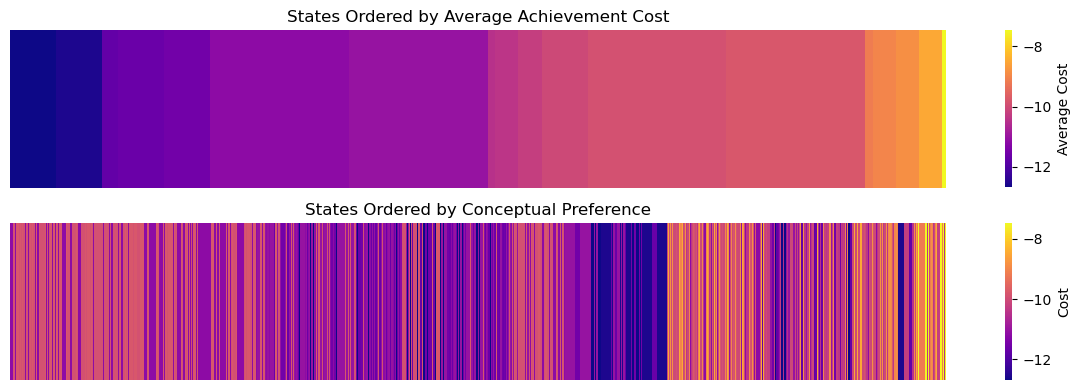

In [73]:
# Create a figure with two subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4))

# First heatmap: States ordered by cost
planner_strategy_sort = planner_strategy.sort_values(by='value', ascending=True).reset_index(drop=True)
planner_strat_reshaped = planner_strategy_sort['value'].values.reshape(-1, 1)
sns.heatmap(planner_strat_reshaped.T, cmap='plasma', 
            cbar_kws={'label': 'Average Cost'}, ax=ax1, rasterized=True)

# Configure labels for first plot
ax1.set_yticks([])
ax1.set_xticks([])
ax1.set_title('States Ordered by Average Achievement Cost')

# Second heatmap: States ordered by conceptual preference
merge_columns = [
    'shape1_sides', 'shape1_shade', 'shape1_texture',
    'shape2_sides', 'shape2_shade', 'shape2_texture',
    'shape3_sides', 'shape3_shade', 'shape3_texture'
]

merged_df = pd.merge(planner_strategy, concept_strategy[merge_columns + ['log_probability_concept']], 
                     on=merge_columns, how='inner')

merged_sort_by_concept = merged_df.copy().sort_values(by='log_probability_concept', ascending=True).reset_index(drop=True)
cost_reshaped_sort_by_concept = merged_sort_by_concept['value'].values.reshape(-1, 1)

sns.heatmap(cost_reshaped_sort_by_concept.T, cmap='plasma', 
            cbar_kws={'label': 'Cost'}, ax=ax2, rasterized=True)

# Configure labels for second plot
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title('States Ordered by Conceptual Preference')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figures first
plt.savefig('figures/heatmap_comparison_cost.svg', 
            format='svg',
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            pad_inches=0.1)

plt.savefig('figures/heatmap_comparison_cost.pdf', 
            format='pdf',
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            pad_inches=0.1)

# plt.savefig('figures/heatmap_comparison_cost.png', 
#             format='png',
#             dpi=300,
#             bbox_inches='tight',
#             transparent=True,
#             pad_inches=0.1)

# Show the plot last
plt.show()

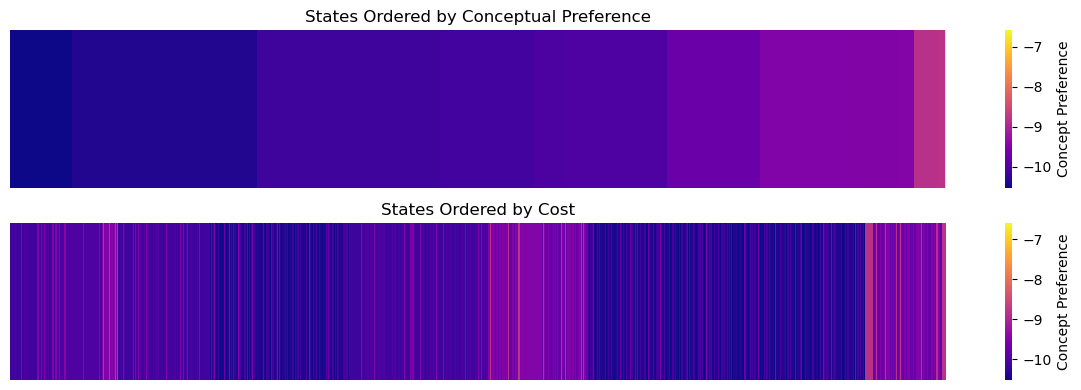

In [72]:
# Create a figure with two subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4))

# First heatmap: States ordered by conceptual preference
concept_strategy_sort = concept_strategy.sort_values(by='log_probability_concept', ascending=True).reset_index(drop=True)
concept_strategy_reshaped = concept_strategy_sort['log_probability_concept'].values.reshape(-1, 1)
sns.heatmap(concept_strategy_reshaped.T, cmap='plasma', 
            cbar_kws={'label': 'Concept Preference'}, ax=ax1, rasterized=True)

# Configure labels for first plot
ax1.set_yticks([])
ax1.set_xticks([])
ax1.set_title('States Ordered by Conceptual Preference')

# Second heatmap: Conceptual preferences ordered by cost
merge_columns = [
    'shape1_sides', 'shape1_shade', 'shape1_texture',
    'shape2_sides', 'shape2_shade', 'shape2_texture',
    'shape3_sides', 'shape3_shade', 'shape3_texture'
]

merged_df = pd.merge(planner_strategy, concept_strategy[merge_columns + ['log_probability_concept']], 
                     on=merge_columns, how='inner')

# Sort by cost, but display conceptual preference
merged_sort_by_cost = merged_df.copy().sort_values(by='value', ascending=True).reset_index(drop=True)
concept_reshaped_sort_by_cost = merged_sort_by_cost['log_probability_concept'].values.reshape(-1, 1)

sns.heatmap(concept_reshaped_sort_by_cost.T, cmap='plasma', 
            cbar_kws={'label': 'Concept Preference'}, ax=ax2, rasterized=True)

# Configure labels for second plot
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title('States Ordered by Cost')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.savefig('figures/heatmap_comparison_concept.pdf', 
            format='pdf',
            dpi=300,
            bbox_inches='tight',
            transparent=False,  # transparent background
            pad_inches=0.1)   # padding around the plot

plt.savefig('figures/heatmap_comparison_concept.svg', 
            format='svg',
            dpi=300,
            bbox_inches='tight',
            transparent=False,  # transparent background
            pad_inches=0.1)   # padding around the plot

plt.show()